# Phase 8 (Stage C, Milestone 1 + dual conditioning) — MusicGen bridge adapter

Trains a small bridge network (`EmbeddingToConditioningBridge`: shared-space 256-d vector → (T, 768) pseudo-sequence) that provides mood-steering conditioning for MusicGen. Everything else — the Stage B `AlignmentModel` and all of MusicGen (T5 text encoder, EnCodec, LM decoder) — stays frozen.

**Dual conditioning** (`stage_c.dual_conditioning: true`, see `project/docs/text_conditioning_bridge_plan.pdf`): rather than the bridge output *replacing* MusicGen's own T5 text-conditioning outright (Milestone 1's original design, which discards all text content beyond the 5-class mood), MusicGen's frozen T5 encoder is run on raw text and its output sequence is **concatenated** with the bridge's mood sequence along the time axis before cross-attention. This lets T5 carry genre/instrumentation/descriptive detail while the bridge supplies an explicit mood signal. Only the bridge is retrained (as `bridge_dual_best.pt`, distinct from the Milestone-1-only `bridge_best.pt`) — no MusicGen parameter ever receives a gradient. See `project/docs/cross_modal_alignment_plan.pdf` §4 for the original 3-milestone roadmap this extends.

Run this notebook top to bottom to watch training progress live and listen to generated samples inline, instead of running `project/training/train_bridge.py` + `project/evaluation/generate_samples.py` as background scripts.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> project/ -> repo root
sys.path.insert(0, str(REPO_ROOT))

from project.config import load_config, resolve_path

cfg = load_config()
sc_cfg = cfg["stage_c"]
a_cfg = cfg["alignment"]

## Step 1 — extract audio targets

Pulls each MATCH clip's own soundtrack via `ffmpeg`, resampled to MusicGen's 32kHz mono EnCodec input format. Idempotent — skips clips already extracted (all 3,189 should already be cached from the earlier run).

In [2]:
from project.features.extract_audio_targets import extract_audio_targets

extract_audio_targets(cfg)

Extracting audio: 100%|██████████| 3189/3189 [00:00<00:00, 43749.54it/s]

Audio targets -> /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/project/features/audio_targets  (extracted 0, already-cached 3189, failed 0)


## Step 2 — train the bridge

Objective: MusicGen's own teacher-forced next-token loss over EnCodec audio codes, with the conditioning source swapped from "T5 embedding of a caption" to "bridge-projected shared-space embedding". Only `bridge.parameters()` get gradients.

Two config-loading quirks in the installed `transformers` version, fixed here (see `train_bridge.py` for the same fixes with fuller comments):
- `labels` passed to `MusicgenForConditionalGeneration.forward` must be shaped `(batch, seq_len, num_codebooks)` — codebooks *last* — not the `(batch*num_codebooks, seq_len)` shape used for the separate `input_ids` argument.
- `musicgen.config.decoder.decoder_start_token_id` loads as `None` even though `generation_config.decoder_start_token_id` (== `pad_token_id` == 2048, the reserved EnCodec pad token) is set correctly; `shift_tokens_right` needs it copied over before training.

In [3]:
import torch
from torch.utils.data import DataLoader
from transformers import MusicgenForConditionalGeneration

from project.models.adapters import AlignmentModel
from project.models.bridge import EmbeddingToConditioningBridge
from project.models.conditioning import build_musicgen_tokenizer, concat_conditioning, t5_encode
from project.models.encoders import get_device
from project.training.train_bridge import VideoEmbeddingAudioDataset, audio_to_labels
from project.training.utils import EarlyStopping, load_checkpoint, save_checkpoint, set_seed

set_seed(cfg["seed"])
device = get_device(sc_cfg["device_preference"])
print(f"Device: {device}")

print(f"Loading {sc_cfg['musicgen_model']} (frozen)...")
musicgen = MusicgenForConditionalGeneration.from_pretrained(sc_cfg["musicgen_model"]).to(device).eval()
if musicgen.config.decoder.decoder_start_token_id is None:
    musicgen.config.decoder.decoder_start_token_id = musicgen.generation_config.decoder_start_token_id
for p in musicgen.parameters():
    p.requires_grad = False
cond_dim = musicgen.config.text_encoder.d_model
print(f"MusicGen conditioning dim (T5 hidden size): {cond_dim}")

dual_conditioning = sc_cfg.get("dual_conditioning", False)
tokenizer = build_musicgen_tokenizer(sc_cfg["musicgen_model"]) if dual_conditioning else None
id2label = {v: k for k, v in cfg["emotion_to_id"].items()} if dual_conditioning else None
text_template = sc_cfg.get("text_template")
print(f"Dual conditioning: {dual_conditioning}")

alignment_model = AlignmentModel(
    shared_dim=a_cfg["shared_dim"], dropout=a_cfg["adapter_dropout"],
    logit_scale_init=a_cfg["logit_scale_init"], logit_scale_max=a_cfg["logit_scale_max"],
).to(device)
load_checkpoint(alignment_model, resolve_path(cfg, "paths.checkpoints_dir") / "alignment_adapters_best.pt",
                 map_location=device)
alignment_model.eval()
for p in alignment_model.parameters():
    p.requires_grad = False

bridge = EmbeddingToConditioningBridge(
    shared_dim=a_cfg["shared_dim"], seq_len=sc_cfg["bridge_seq_len"], cond_dim=cond_dim,
    hidden_dim=sc_cfg["bridge_hidden_dim"], n_heads=sc_cfg["bridge_n_heads"],
    n_layers=sc_cfg["bridge_n_layers"], dropout=sc_cfg["bridge_dropout"],
).to(device)

video_dir = resolve_path(cfg, "paths.video_embedding_512_dir")
audio_dir = resolve_path(cfg, "paths.audio_targets_dir")
train_ds = VideoEmbeddingAudioDataset(
    resolve_path(cfg, "paths.train_csv"), video_dir, audio_dir,
    sc_cfg["audio_sample_rate"], sc_cfg["audio_channels"], sc_cfg["clip_duration_s"],
    id2label=id2label, text_template=text_template,
    subset_size=sc_cfg["subset_size"], seed=cfg["seed"],
)
val_ds = VideoEmbeddingAudioDataset(
    resolve_path(cfg, "paths.val_csv"), video_dir, audio_dir,
    sc_cfg["audio_sample_rate"], sc_cfg["audio_channels"], sc_cfg["clip_duration_s"],
    id2label=id2label, text_template=text_template,
    subset_size=max(sc_cfg["subset_size"] // 5, 10), seed=cfg["seed"],
)
print(f"train: {len(train_ds)}  val: {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=sc_cfg["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=sc_cfg["batch_size"], shuffle=False)

Device: mps
Loading facebook/musicgen-small (frozen)...


[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

MusicGen conditioning dim (T5 hidden size): 768
Dual conditioning: True
train: 2232  val: 479


In [4]:
from tqdm.notebook import tqdm

optimizer = torch.optim.AdamW(bridge.parameters(), lr=sc_cfg["lr"], weight_decay=sc_cfg["weight_decay"])
early_stopping = EarlyStopping(patience=sc_cfg["early_stopping_patience"], mode="min")
checkpoint_name = sc_cfg["bridge_checkpoint_name"] if dual_conditioning else "bridge_best.pt"
checkpoint_path = resolve_path(cfg, "paths.checkpoints_dir") / checkpoint_name
history = {"train_loss": [], "val_loss": []}

start_epoch = 1
if sc_cfg.get("resume", False) and checkpoint_path.exists():
    ckpt = load_checkpoint(bridge, checkpoint_path, optimizer=optimizer, map_location=device)
    start_epoch = ckpt["epoch"] + 1
    early_stopping.best_score = ckpt["metrics"]["val_loss"]
    print(f"Resumed from {checkpoint_path} (epoch {ckpt['epoch']}, "
          f"best val_loss={early_stopping.best_score:.4f}) -- continuing at epoch {start_epoch}")


def run_epoch(loader, train: bool):
    bridge.train(train)
    total_loss, n_batches = 0.0, 0
    for batch in tqdm(loader, leave=False):
        if dual_conditioning:
            video_emb, waveform, _labels, _video_ids, texts = batch
        else:
            video_emb, waveform, _labels, _video_ids = batch
        video_emb, waveform = video_emb.to(device), waveform.to(device)
        with torch.no_grad():
            shared_z = alignment_model.encode_video(video_emb)
        bridge_out = bridge(shared_z)
        bridge_mask = bridge.attention_mask(bridge_out.shape[0], device)

        if dual_conditioning:
            t5_hidden, t5_mask = t5_encode(musicgen, tokenizer, texts, device, sc_cfg["text_max_length"])
            cond, attn_mask = concat_conditioning(t5_hidden, t5_mask, bridge_out, bridge_mask)
        else:
            cond, attn_mask = bridge_out, bridge_mask

        codec_labels = audio_to_labels(musicgen, waveform)

        out = musicgen(encoder_outputs=(cond,), attention_mask=attn_mask, labels=codec_labels)
        loss = out.loss

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


for epoch in range(start_epoch, sc_cfg["max_epochs"] + 1):
    train_loss = run_epoch(train_loader, train=True)
    with torch.no_grad():
        val_loss = run_epoch(val_loader, train=False)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"[bridge] epoch {epoch:03d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if early_stopping.step(val_loss):
        save_checkpoint(bridge, optimizer, epoch, {"val_loss": val_loss}, checkpoint_path)
    if early_stopping.should_stop:
        print(f"[bridge] early stopping at epoch {epoch} (best val_loss={early_stopping.best_score:.4f})")
        break

Resumed from /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/project/training/checkpoints/bridge_dual_best.pt (epoch 9, best val_loss=5.6962) -- continuing at epoch 10


  0%|          | 0/558 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

[bridge] epoch 010  train_loss=5.7399  val_loss=5.6917


  0%|          | 0/558 [00:00<?, ?it/s]

...

  0%|          | 0/120 [00:00<?, ?it/s]

[bridge] epoch 015  train_loss=5.9682  val_loss=5.9214


  0%|          | 0/558 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

KeyboardInterrupt: 

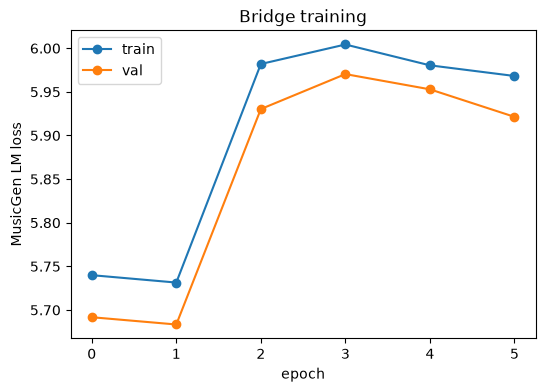

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], marker="o", label="train")
plt.plot(history["val_loss"], marker="o", label="val")
plt.xlabel("epoch"); plt.ylabel("MusicGen LM loss"); plt.legend(); plt.title("Bridge training")
plt.show()

## Step 3 — generate & listen to samples

Two sources, on purpose:
1. **TEXT anchors** (the 5 fixed class-name strings) — out-of-distribution for the bridge, since it only ever trained on video embeddings. Tests whether Stage B's cross-modal alignment actually transfers to steering MusicGen from text alone.
2. Real **VIDEO embeddings** from held-out test clips — in-distribution, what the bridge was actually trained on.

Per the dual-conditioning plan's three-way ablation (§4), each example is generated three ways: **T5-only** (`cond = T5(text)`, stock MusicGen — the baseline the combined approach must beat on mood-consistency), **bridge-only** (`cond = bridge(z)`, the original Milestone 1 design — the baseline it must not regress against), and **combined** (`cond = concat(T5(text), bridge(z))`, the proposed approach).

`guidance_scale=1.0` is set explicitly: MusicGen's default classifier-free guidance path duplicates the batch against a null/unconditional embedding internally when conditioning via raw `input_ids`, which doesn't apply when handing it custom `encoder_outputs` directly.

In [ ]:
import torchaudio
from IPython.display import Audio, display

from project.datasets.feature_dataset import CachedEmbeddingDataset
from project.evaluation.generate_samples import generate_from_conditioning
from project.models.conditioning import label_template_text
from project.training.alignment_common import load_text_anchors

load_checkpoint(bridge, checkpoint_path, map_location=device)
bridge.eval()

out_dir = resolve_path(cfg, "paths.results_dir") / "generated_samples_combined"
out_dir.mkdir(parents=True, exist_ok=True)
sample_rate = sc_cfg["audio_sample_rate"]
max_new_tokens = int(sc_cfg["clip_duration_s"] * 50)  # EnCodec's ~50 Hz frame rate at this config
text_max_length = sc_cfg.get("text_max_length", 64)
text_template = sc_cfg.get("text_template", "{emotion} instrumental music")


@torch.no_grad()
def generate_ablations(raw_texts, z):
    """raw_texts: list[str] (len B), z: (B, shared_dim) mood vector (already
    adapter-encoded) -> {tag: (B, 1, n_samples) audio} for the three-way
    ablation: T5-only, bridge-only, combined."""
    bridge_out = bridge(z)
    bridge_mask = bridge.attention_mask(bridge_out.shape[0], device)
    t5_hidden, t5_mask = t5_encode(musicgen, tokenizer, raw_texts, device, text_max_length)
    combined_cond, combined_mask = concat_conditioning(t5_hidden, t5_mask, bridge_out, bridge_mask)
    return {
        "t5only": generate_from_conditioning(musicgen, t5_hidden, t5_mask, max_new_tokens),
        "bridgeonly": generate_from_conditioning(musicgen, bridge_out, bridge_mask, max_new_tokens),
        "combined": generate_from_conditioning(musicgen, combined_cond, combined_mask, max_new_tokens),
    }

In [ ]:
print("--- TEXT anchors (out-of-distribution for the bridge) ---")
text_z_raw, id2label = load_text_anchors(cfg, device)
with torch.no_grad():
    text_z = alignment_model.encode_text(text_z_raw.to(device))
raw_texts = [id2label[i] for i in range(len(id2label))]  # same row order as text_z_raw
audio_by_tag = generate_ablations(raw_texts, text_z)

for i, label in id2label.items():
    print(label)
    for tag, audio in audio_by_tag.items():
        path = out_dir / f"text_{label}_{tag}.wav"
        torchaudio.save(str(path), audio[i].cpu(), sample_rate)
        print(f"  {tag}")
        display(Audio(audio[i].cpu().numpy(), rate=sample_rate))

In [ ]:
print("--- VIDEO embeddings from held-out test clips (in-distribution) ---")
video_dir = resolve_path(cfg, "paths.video_embedding_512_dir")
test_ds = CachedEmbeddingDataset(resolve_path(cfg, "paths.test_csv"), [(video_dir, "video_id")])
picked = {}
for i in range(len(test_ds)):
    x, label, vid = test_ds[i]
    if label not in picked:
        picked[label] = (x, vid)
    if len(picked) == len(id2label):
        break

for label_id, (x, vid) in picked.items():
    with torch.no_grad():
        z = alignment_model.encode_video(x.unsqueeze(0).to(device))
    raw_text = label_template_text([label_id], id2label, text_template)  # no per-clip captions available
    audio_by_tag = generate_ablations(raw_text, z)
    print(f"{id2label[label_id]}  ({vid})")
    for tag, audio in audio_by_tag.items():
        path = out_dir / f"video_{id2label[label_id]}_{vid}_{tag}.wav"
        torchaudio.save(str(path), audio[0].cpu(), sample_rate)
        print(f"  {tag}")
        display(Audio(audio[0].cpu().numpy(), rate=sample_rate))

## Next

Listen across the three-way ablation for each class/example: does **combined** hold mood-consistency close to **bridge-only**, and does it improve content specificity (audible instrumentation/genre cues) over **bridge-only** by actually using what **T5-only** already carries? A collapse to one branch (combined sounds identical to one of the other two) is the clearest sign the bridge needs more retraining or a rebalanced loss (see plan doc §4's optional cross-attention diagnostic). If the combined approach holds up, it replaces Milestone 1's single-source design; proceed to Milestone 2 (LoRA/adapter fine-tuning of MusicGen's cross-attention blocks) only if this plateaus, budgeting cloud GPU time per the alignment plan's §`sec:compute`.